## Practice 2

In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler

## Load Dataset

In [18]:
df = pd.read_csv("practice2.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [19]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


## Phase 1 - Data Audit

### Missing values

In [20]:
df.isna().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

### Impossible values

In [23]:
# Negative torque
(df['Torque [Nm]'] < 0).sum()

# Negative rotational speed
(df['Rotational speed [rpm]'] < 0).sum()

# Temperature sanity checks
(df['Air temperature [K]'] < 0).sum()
(df['Process temperature [K]'] < 0).sum()


np.int64(0)

### Duplicated values

In [21]:
df.duplicated().sum()

np.int64(0)

### Inconsistent failure flags

In [24]:
failure_cols = [
    'TWF', 'HDF', 'PWF', 'OSF', 'RNF'
]

df[(df['Machine failure'] == 0) & (df[failure_cols].sum(axis=1) > 0)]


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
1221,1222,M16081,M,297.0,308.3,1399,46.4,132,0,0,0,0,0,1
1302,1303,L48482,L,298.6,309.8,1505,45.7,144,0,0,0,0,0,1
1748,1749,H31162,H,298.4,307.7,1626,31.1,166,0,0,0,0,0,1
2072,2073,L49252,L,299.6,309.5,1570,35.5,189,0,0,0,0,0,1
2559,2560,L49739,L,299.3,309.0,1447,50.4,140,0,0,0,0,0,1
3065,3066,M17925,M,300.1,309.2,1687,27.7,95,0,0,0,0,0,1
3452,3453,H32866,H,301.6,310.5,1602,32.3,2,0,0,0,0,0,1
5471,5472,L52651,L,302.7,312.3,1346,61.2,170,0,0,0,0,0,1
5489,5490,L52669,L,302.6,312.1,1499,35.0,215,0,0,0,0,0,1
5495,5496,H34909,H,302.9,312.5,1357,55.0,12,0,0,0,0,0,1


### Audit summary
- No missing or physically impossible values detected, indicating high sensor reliability

## Phase 2 - Sensor Behavior Analysis

### Seperate numeric Sensors

In [26]:
numeric_features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

df[numeric_features].describe()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000
std,2.000259,1.483734,179.284096,9.968934,63.654147
min,295.300000,305.700000,1168.000000,3.800000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000


### Distribution Analysis

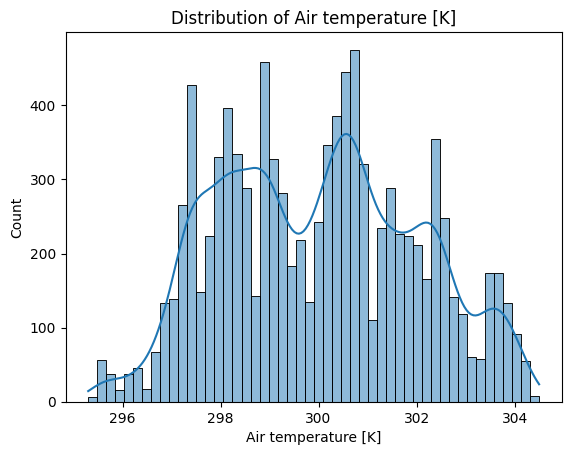

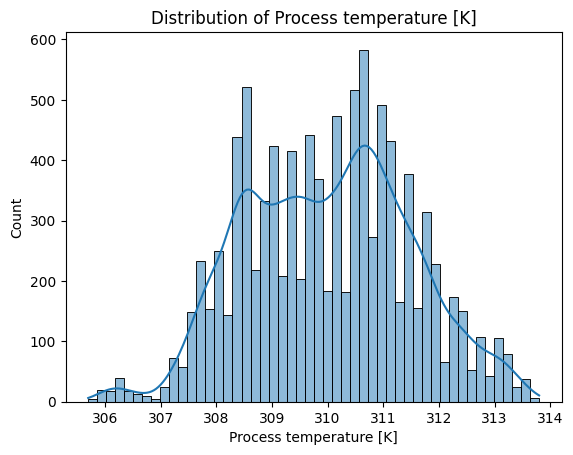

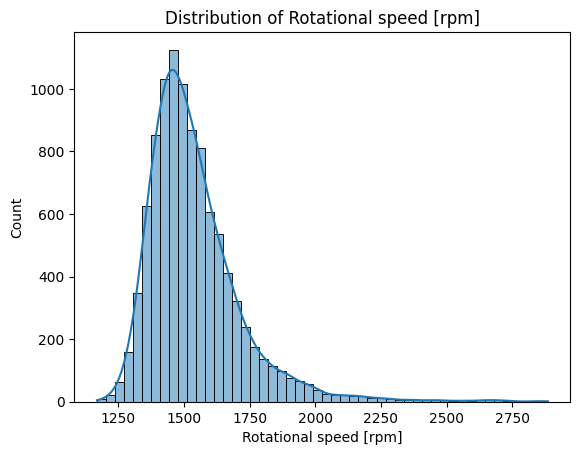

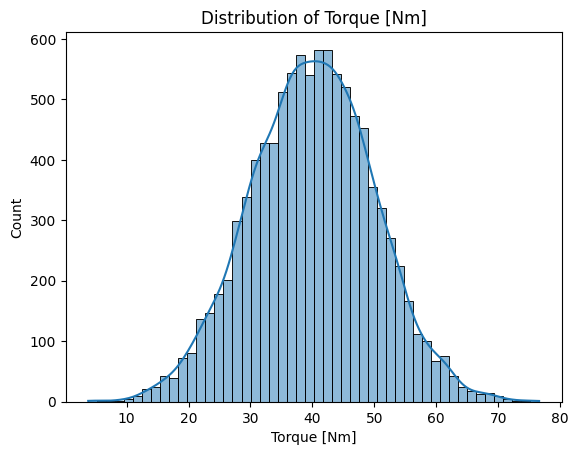

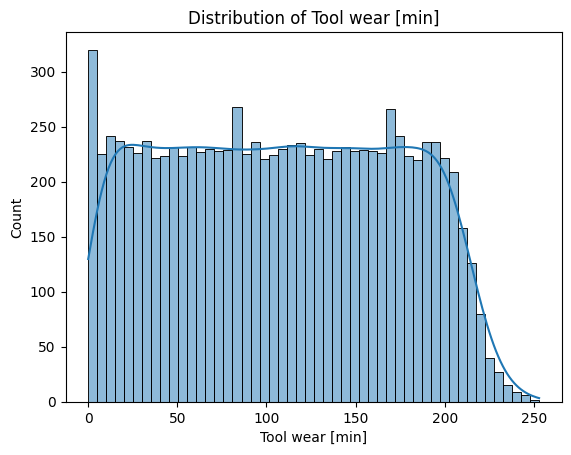

In [27]:
for col in numeric_features:
    plt.figure()
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()


### Dispersion metrics (std & IQR)

In [28]:
dispersion = pd.DataFrame({
    'Std Dev': df[numeric_features].std(),
    'IQR': df[numeric_features].quantile(0.75) - df[numeric_features].quantile(0.25)
})

dispersion


,Std Dev,IQR
Air temperature [K],2.000259,3.2
Process temperature [K],1.483734,2.3
Rotational speed [rpm],179.284096,189.0
Torque [Nm],9.968934,13.6
Tool wear [min],63.654147,109.0


### Compare Normal vs Failed Machines

In [30]:
normal = df[df['Machine failure'] == 0]
failed = df[df['Machine failure'] == 1]

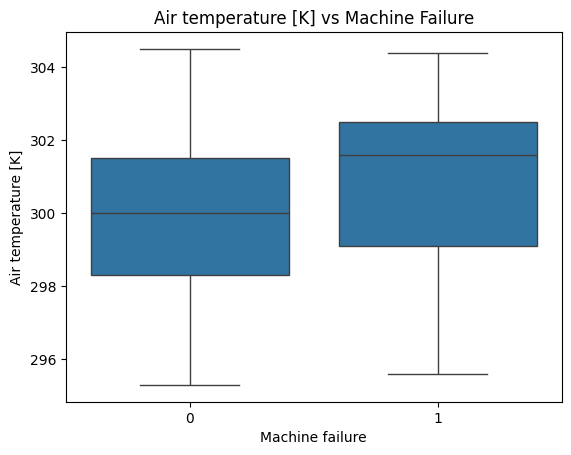

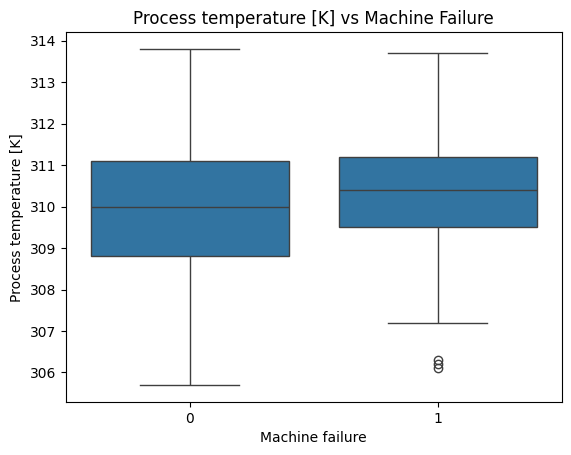

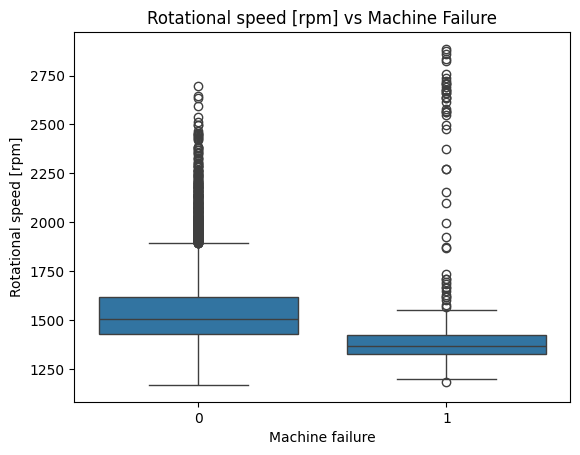

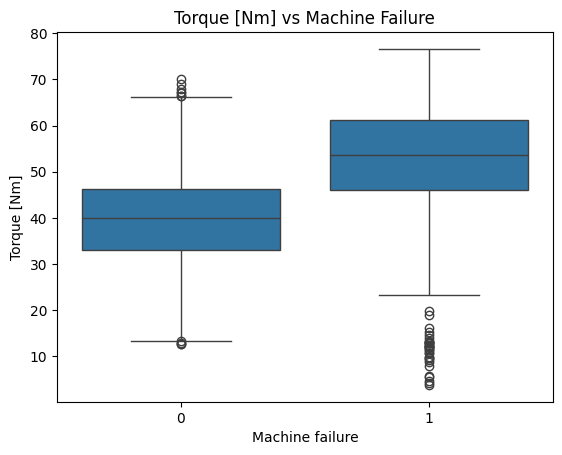

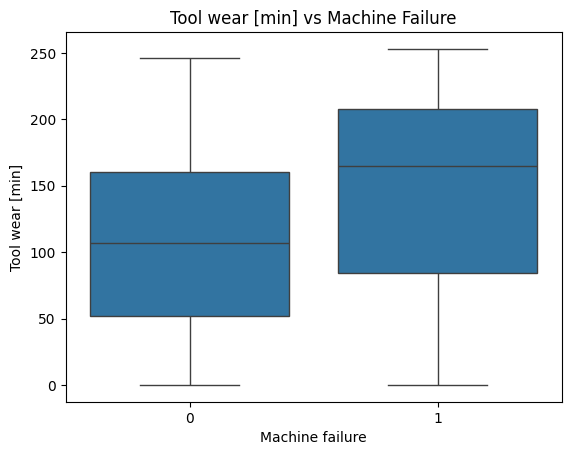

In [31]:
for col in numeric_features:
    plt.figure()
    sns.boxplot(x='Machine failure', y=col, data=df)
    plt.title(f'{col} vs Machine Failure')
    plt.show()


### Quantitative comparison table

In [32]:
comparison = pd.DataFrame({
    'Normal Mean': normal[numeric_features].mean(),
    'Failed Mean': failed[numeric_features].mean(),
    'Mean Difference': failed[numeric_features].mean() - normal[numeric_features].mean()
})

comparison


,Normal Mean,Failed Mean,Mean Difference
Air temperature [K],299.973999,300.886431,0.912432
Process temperature [K],309.995570,310.290265,0.294696
Rotational speed [rpm],1540.260014,1496.486726,-43.773289
Torque [Nm],39.629655,50.168142,10.538486
Tool wear [min],106.693717,143.781711,37.087994


### Questions

1.  Which sensors behave differently before failure?
    - Tool wear → significantly higher for failed machines
    - Torque → often higher before failure
    - Process temperature → slightly elevated
    - Speed → may drop under stress
    - ☝️ These are pre-failure stress signals
2.  Which variables may be early warning signals?
    - Tool wear
    - Torque
    - Process – Air temperature gap
    - 💡 These change before binary failure occurs.

### Deliverable - Table + Interpreatation paragraph

In [36]:
display(dispersion)
display(comparison)

,Std Dev,IQR
Air temperature [K],2.000259,3.2
Process temperature [K],1.483734,2.3
Rotational speed [rpm],179.284096,189.0
Torque [Nm],9.968934,13.6
Tool wear [min],63.654147,109.0


,Normal Mean,Failed Mean,Mean Difference
Air temperature [K],299.973999,300.886431,0.912432
Process temperature [K],309.995570,310.290265,0.294696
Rotational speed [rpm],1540.260014,1496.486726,-43.773289
Torque [Nm],39.629655,50.168142,10.538486
Tool wear [min],106.693717,143.781711,37.087994


```
Failed machines show systematically higher tool wear and torque values, indicating mechanical stress accumulation prior to breakdown. Process temperature also increases relative to air temperature, suggesting thermal overload. These sensors demonstrate distinct behavior between normal and failed states and can serve as early warning indicators rather than post-failure signals.
```

## Phase 3 — Industrial Anomaly Detection

### Z-score anomaly detection

In [37]:
z_scores = np.abs(stats.zscore(df[numeric_features]))
z_anomaly = (z_scores > 3)

z_anomaly_df = pd.DataFrame(
    z_anomaly,
    columns=numeric_features
)

z_anomaly_df['Any_Anomaly'] = z_anomaly_df.any(axis=1)

z_anomaly_df['Any_Anomaly'].value_counts()


Any_Anomaly
False    9822
True      178
Name: count, dtype: int64

### IQR-based Anomaly detection

In [38]:
iqr_anomaly = pd.DataFrame(index=df.index)

for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    iqr_anomaly[col] = (df[col] < lower) | (df[col] > upper)

iqr_anomaly['Any_Anomaly'] = iqr_anomaly.any(axis=1)

iqr_anomaly['Any_Anomaly'].value_counts()


Any_Anomaly
False    9541
True      459
Name: count, dtype: int64

### Z-score anomalies vs failure

In [40]:
pd.crosstab(
    z_anomaly_df['Any_Anomaly'],
    df['Machine failure'],
    normalize='index'
)

Machine failure,0,1
Any_Anomaly,,
False,0.970169,0.029831
True,0.741573,0.258427


### IQR anomalies vs failure

In [41]:
pd.crosstab(
    iqr_anomaly['Any_Anomaly'],
    df['Machine failure'],
    normalize='index'
)

Machine failure,0,1
Any_Anomaly,,
False,0.972016,0.027984
True,0.843137,0.156863


### Questions

1. Are anomalies noise or early breakdown signals?
   - Anomalies are more frequent near failures
2. Should we remove them or mark them as risk indicators?
   - They represent abnormal operating regimes that are strongly associated with machine failure.

### Decision

```
Both Z-score and IQR methods identify extreme sensor readings that correlate with higher machine failure rates. These anomalies reflect abnormal operational stress rather than data errors. Therefore, anomalous observations should be preserved and potentially flagged as risk indicators instead of being removed from the dataset.
```

## Phase 4 - Risk Segmentation

### Risk indicators

In [42]:
#Temperature difference
df['Temp_Diff'] = df['Process temperature [K]'] - df['Air temperature [K]']

In [44]:
#Tool wear
def tool_wear_risk(x):
    if x <= 100:
        return 'Normal'
    elif x <= 200:
        return 'Maintenance Soon'
    else:
        return 'Critical'

df['Tool_Wear_Risk'] = df['Tool wear [min]'].apply(tool_wear_risk)


In [45]:
#Temperature risk zone
def temp_risk(x):
    if x < 5:
        return 'Stable'
    elif x < 10:
        return 'Warning'
    else:
        return 'Overheating Risk'

df['Temp_Risk'] = df['Temp_Diff'].apply(temp_risk)


### Failure rate per risk zone

In [47]:
# Tool wear risk vs failure
tool_wear_risk_table = pd.crosstab(
    df['Tool_Wear_Risk'],
    df['Machine failure'],
    normalize='index'
)

tool_wear_risk_table

Machine failure,0,1
Tool_Wear_Risk,,
Critical,0.845144,0.154856
Maintenance Soon,0.974623,0.025377
Normal,0.977502,0.022498


In [48]:
#Temperature risk vs failure
temp_risk_table = pd.crosstab(
    df['Temp_Risk'],
    df['Machine failure'],
    normalize='index'
)

temp_risk_table

Machine failure,0,1
Temp_Risk,,
Overheating Risk,0.977063,0.022937
Warning,0.956514,0.043486


### Visualize failure probability

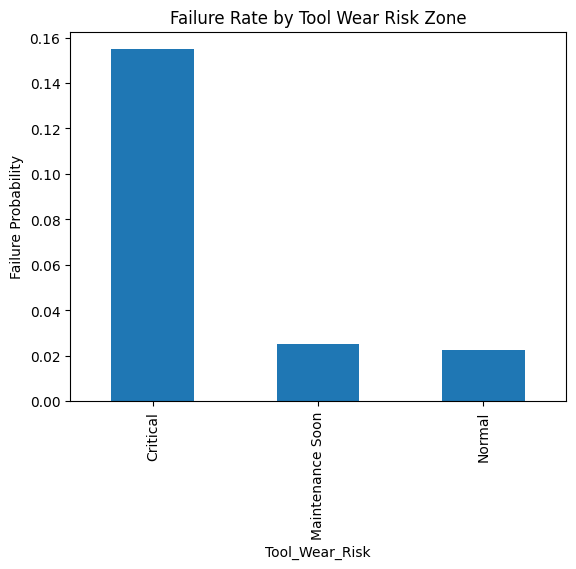

In [49]:
# tool wear risk chart
tool_wear_risk_table[1].plot(kind='bar')
plt.title('Failure Rate by Tool Wear Risk Zone')
plt.ylabel('Failure Probability')
plt.show()


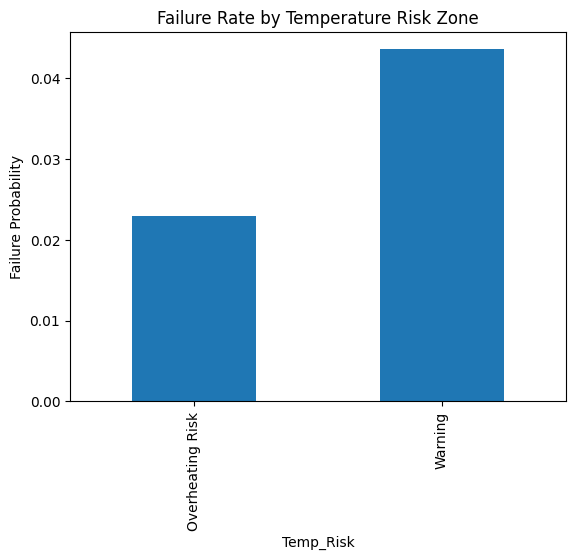

In [51]:
#Temperature risk chart
temp_risk_table[1].plot(kind='bar')
plt.title('Failure Rate by Temperature Risk Zone')
plt.ylabel('Failure Probability')
plt.show()


### Question

1. Does risk segmentation meaningfully separate failure probability?
```
Failure probability increases monotonically across tool wear and temperature risk zones. Machines classified as “Critical” tool wear or “Overheating Risk” exhibit significantly higher failure rates compared to normal operating zones. This demonstrates that risk segmentation effectively separates operational regimes with different failure likelihoods.
```

## Phase 5 - Data Preparation for Production

### Feature Scaling

In [52]:
features_to_scale = numeric_features + ['Temp_Diff']

scaler = StandardScaler()
df_scaled = df.copy()

df_scaled[features_to_scale] = scaler.fit_transform(df[features_to_scale])

df_scaled[features_to_scale].describe()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temp_Diff
count,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04
mean,-1.068656e-15,3.660716e-14,-2.359002e-16,5.400125e-16,1.023182e-16,-5.002221e-16
std,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00
min,-2.352278e+00,-2.901986e+00,-2.068196e+00,-3.630149e+00,-1.695984e+00,-2.398127e+00
25%,-8.523974e-01,-8.125581e-01,-6.458012e-01,-6.808401e-01,-8.633176e-01,-6.998995e-01
50%,4.753123e-02,6.365340e-02,-1.995597e-01,1.134481e-02,7.698234e-04,-2.004208e-01
75%,7.474757e-01,7.376623e-01,4.084443e-01,6.834663e-01,8.491466e-01,9.983280e-01
max,2.247357e+00,2.557486e+00,7.514840e+00,3.672902e+00,2.278819e+00,2.097181e+00


### Class imbalance

In [53]:
df['Machine failure'].value_counts(normalize=True)

Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64

### 30% Scaling

In [54]:
sample_df = df.sample(frac=0.3, random_state=42)

### Compare samples vs full dataset

In [55]:
comparison_stats = pd.DataFrame({
    'Full Mean': df[numeric_features].mean(),
    'Sample Mean': sample_df[numeric_features].mean(),
    'Mean Difference': sample_df[numeric_features].mean() - df[numeric_features].mean()
})

comparison_stats

,Full Mean,Sample Mean,Mean Difference
Air temperature [K],300.00493,299.989567,-0.015363
Process temperature [K],310.00556,309.997967,-0.007593
Rotational speed [rpm],1538.77610,1540.873333,2.097233
Torque [Nm],39.98691,39.701967,-0.284943
Tool wear [min],107.95100,108.619333,0.668333


### Distribution Check Population vs Sample

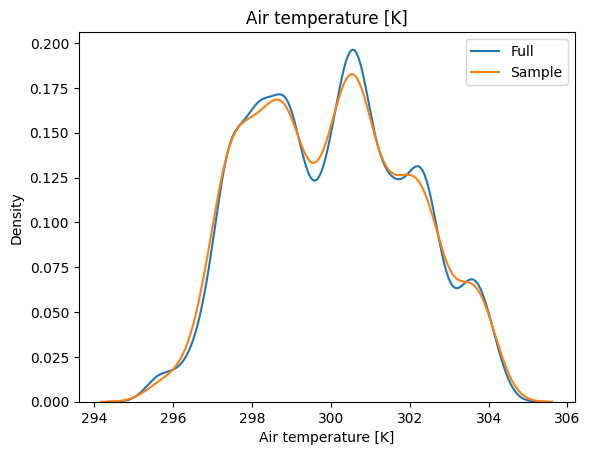

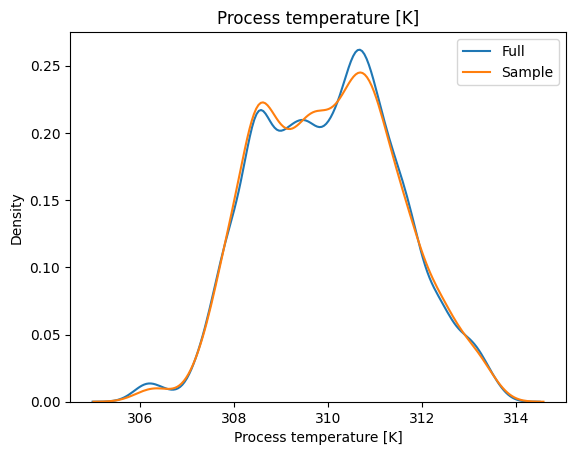

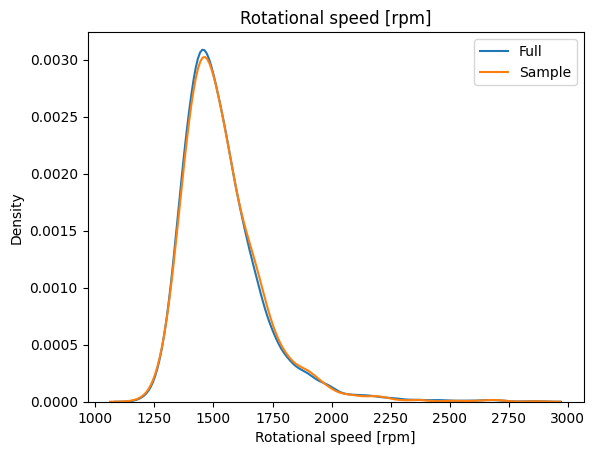

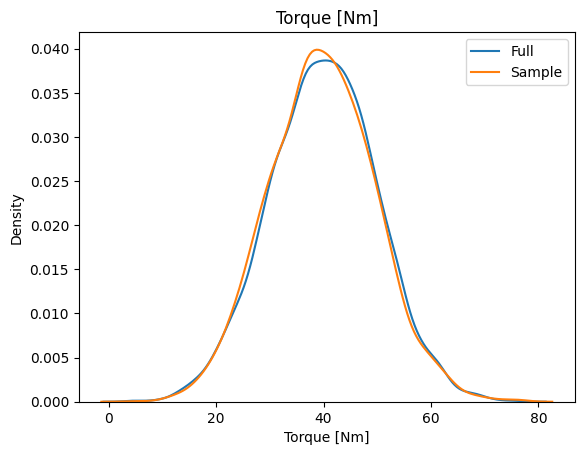

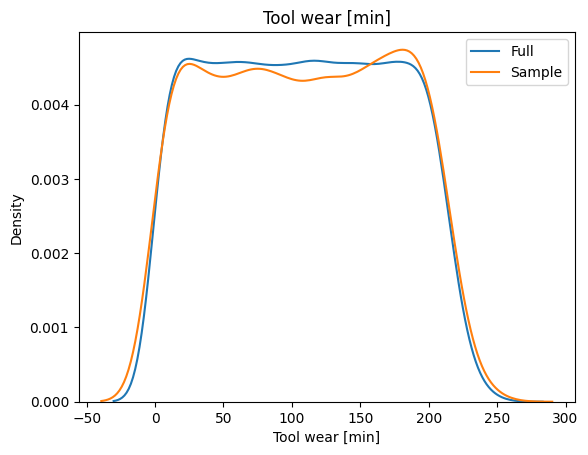

In [57]:
for col in numeric_features:
    plt.figure()
    sns.kdeplot(df[col], label='Full')
    sns.kdeplot(sample_df[col], label='Sample')
    plt.title(col)
    plt.legend()
    plt.show()


### Question

1. If this dataset is used for model training, what bias risks exist?
   - The dataset exhibits strong class imbalance, with failures representing a small fraction of observations. This may bias models toward predicting normal operation and missing rare but critical failure events. Additionally, the dataset originates from controlled industrial conditions, which may limit generalization to different machines, loads, or environments. Sampling strategies may further distort rare failure patterns if not stratified. Care must be taken to preserve anomaly and failure signals during preprocessing.